# 🦉 Advanced Simulator: The Ethics of the Frame

### Welcome, Philosophers!
Susan Sontag argued that taking a photograph is an act of power. The photographer decides what is included in the frame and what is excluded, fundamentally altering the "truth" of a situation. 

Roland Barthes argued that while the photographer tries to control the narrative (the *Studium*), the viewer's eye is often pierced by an unintended, tiny detail (the *Punctum*).

In this notebook, we will use Python to simulate a complex documentary scene. We will then act as the photographer, using code to crop the image and manipulate the ethical truth of the event.

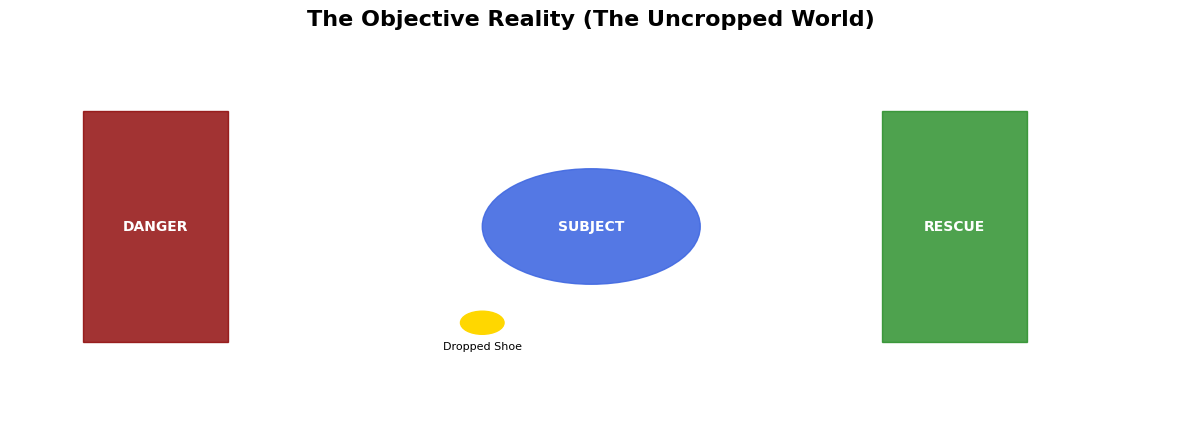

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_complex_scene():
    """
    Generates a wide-angle 'documentary' scene containing three distinct narrative elements.
    """
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # Create a neutral background (the street/environment)
    ax.set_facecolor('#e0e0e0')
    
    # 1. Left side: The Aggressor/Danger (Red)
    ax.add_patch(patches.Rectangle((1, 2), 2, 6, color='darkred', alpha=0.8))
    ax.text(2, 5, "DANGER", color='white', fontweight='bold', ha='center', va='center')
    
    # 2. Center: The Vulnerable Subject (Blue)
    ax.add_patch(patches.Circle((8, 5), 1.5, color='royalblue', alpha=0.9))
    ax.text(8, 5, "SUBJECT", color='white', fontweight='bold', ha='center', va='center')
    
    # 3. Right side: The Helper/Rescue (Green)
    ax.add_patch(patches.Rectangle((12, 2), 2, 6, color='forestgreen', alpha=0.8))
    ax.text(13, 5, "RESCUE", color='white', fontweight='bold', ha='center', va='center')
    
    # 4. The Tiny Detail (The Punctum)
    # A tiny, seemingly irrelevant dropped object near the subject
    ax.add_patch(patches.Circle((6.5, 2.5), 0.3, color='gold'))
    ax.text(6.5, 1.8, "Dropped Shoe", fontsize=8, ha='center')

    ax.set_title("The Objective Reality (The Uncropped World)", fontsize=16, fontweight='bold')
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    plt.show()

# Run the scene generator!
generate_complex_scene()

### ✂️ The Power of the Crop (Sontag's Aggression)
The image above represents the objective truth of the street. There is danger, a vulnerable subject, and rescue arriving. 

But a photograph cannot capture the entire world. The photographer *must* draw a box around something. Let's see how the photographer's choice of framing completely changes the ethical truth of the document.

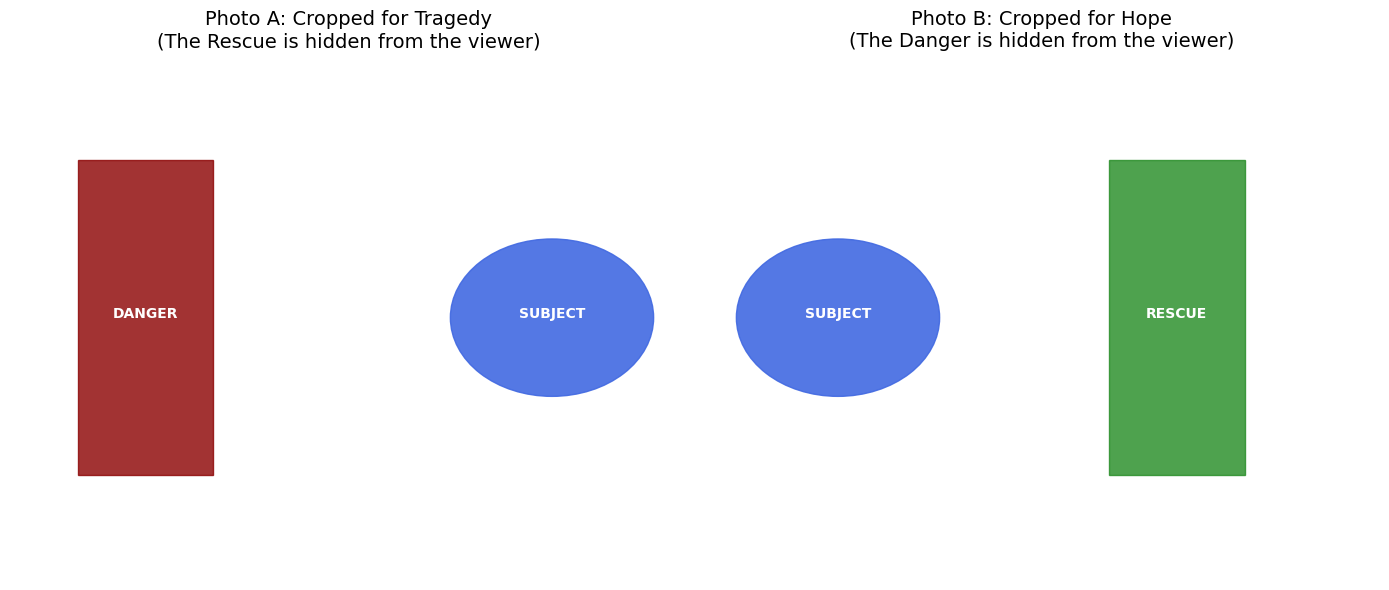

In [2]:
def simulate_ethical_framing():
    """
    Simulates how cropping changes the narrative truth of a single photograph.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- PHOTOGRAPH A: The Narrative of Despair ---
    axes[0].set_facecolor('#e0e0e0')
    axes[0].add_patch(patches.Rectangle((1, 2), 2, 6, color='darkred', alpha=0.8))
    axes[0].add_patch(patches.Circle((8, 5), 1.5, color='royalblue', alpha=0.9))
    axes[0].text(2, 5, "DANGER", color='white', fontweight='bold', ha='center')
    axes[0].text(8, 5, "SUBJECT", color='white', fontweight='bold', ha='center')
    
    axes[0].set_xlim(0, 10) # Cropped to exclude the right side
    axes[0].set_ylim(0, 10)
    axes[0].axis('off')
    axes[0].set_title("Photo A: Cropped for Tragedy\n(The Rescue is hidden from the viewer)", fontsize=14)

    # --- PHOTOGRAPH B: The Narrative of Hope ---
    axes[1].set_facecolor('#e0e0e0')
    axes[1].add_patch(patches.Circle((8, 5), 1.5, color='royalblue', alpha=0.9))
    axes[1].add_patch(patches.Rectangle((12, 2), 2, 6, color='forestgreen', alpha=0.8))
    axes[1].text(8, 5, "SUBJECT", color='white', fontweight='bold', ha='center')
    axes[1].text(13, 5, "RESCUE", color='white', fontweight='bold', ha='center')
    
    axes[1].set_xlim(6, 16) # Cropped to exclude the left side
    axes[1].set_ylim(0, 10)
    axes[1].axis('off')
    axes[1].set_title("Photo B: Cropped for Hope\n(The Danger is hidden from the viewer)", fontsize=14)

    plt.tight_layout()
    plt.show()

# Run the framing simulator!
simulate_ethical_framing()

### ⚖️ Analysis: Which Photo is True?
Both Photo A and Photo B are 100% "real" photographs. Neither was faked or photoshopped. Yet, if Photo A is printed in a newspaper, the public feels despair. If Photo B is printed, the public feels relief.

This is the ethical burden Sontag warns us about. The camera does not tell the objective truth; it tells the *photographer's* truth. 

---

### 📌 Barthes and the Punctum (Visual Attention)
Roland Barthes argued that despite the photographer's aggressive framing (the *Studium*), the viewer's eye will often drift to an accidental detail that breaks the narrative. This detail "wounds" the viewer. It is the *Punctum*.

Let's generate a heat map to simulate where the photographer *wants* you to look, versus where Barthes says the emotional weight actually lies.

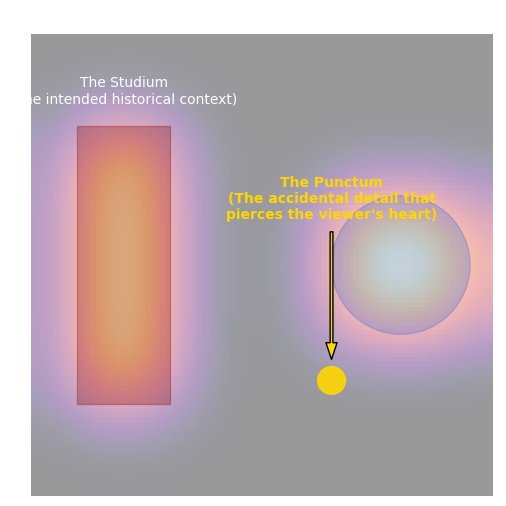

In [3]:
from scipy.ndimage import gaussian_filter

def simulate_the_punctum():
    """
    Simulates an attention heat map contrasting the intended narrative (Studium) 
    with the accidental emotional detail (Punctum).
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#202020') # Darkroom background
    
    # Re-draw the "Despair" crop
    ax.add_patch(patches.Rectangle((1, 2), 2, 6, color='darkred', alpha=0.3))
    ax.add_patch(patches.Circle((8, 5), 1.5, color='royalblue', alpha=0.3))
    ax.add_patch(patches.Circle((6.5, 2.5), 0.3, color='gold', alpha=0.9)) # The dropped shoe is bright!
    
    # Simulate the "Studium" attention (Broad, cultural context of the tragedy)
    # The photographer wants you to look at the massive red and blue shapes
    studium_heatmap = np.zeros((100, 100))
    studium_heatmap[20:80, 10:30] = 0.5
    studium_heatmap[35:65, 65:95] = 0.5
    studium_heatmap = gaussian_filter(studium_heatmap, sigma=8)
    
    ax.imshow(studium_heatmap, extent=[0, 10, 0, 10], cmap='inferno', alpha=0.4)
    
    # Annotate the Philosophy
    ax.text(2, 8.5, "The Studium\n(The intended historical context)", color='white', ha='center')
    
    ax.annotate("The Punctum\n(The accidental detail that\npierces the viewer's heart)", 
                xy=(6.5, 2.8), xytext=(6.5, 6),
                arrowprops=dict(facecolor='gold', shrink=0.05, width=2, headwidth=8),
                color='gold', ha='center', fontweight='bold')

    ax.set_title("Barthes's Heat Map: Studium vs. Punctum", fontsize=16, color='white')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    plt.show()

# Run the Punctum simulator!
simulate_the_punctum()

### 📸 Conclusion: The Indexical Trace
The dropped shoe (the golden dot) might seem irrelevant to the news story, but to Barthes, it is the proof of reality. It proves that this was a real person, in a real place, who lost their shoe in the chaos. 

As we move into an era of AI-generated imagery, Sontag and Barthes's theories become even more vital. If an image is perfectly generated by a computer, there is no physical "trace" of light. There is no accident. Therefore, can an AI image ever possess a true *Punctum*?